# Alternative Strategies for Encoding High-Cardinality Categorical Variables

One-hot encoding is a standard way to represent categorical variables. However, features such as ZIP code, city, neighborhood, or zoning description may contain hundreds of distinct values. One-hot encoding these variables can produce thousands of predictor columns.

This experiment compares four approaches:

1. Dense one-hot encoding
2. Sparse one-hot encoding
3. Grouping infrequent categories
4. Frequency Encoding
5. Mixed encoding (Dense & Frequency)

In [1]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 


In [2]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

In [10]:
# ------------------------------------------------------------
# Identify numeric and categorical predictor columns
# ------------------------------------------------------------

TARGET_COLUMN = "taxvaluedollarcnt"

X = df.drop(columns=[TARGET_COLUMN])

numeric_columns = (
    X.select_dtypes(include="number")
    .columns
    .tolist()
)

categorical_columns = (
    X.select_dtypes(exclude="number")
    .columns
    .tolist()
)

print(f"Numeric columns:     {len(numeric_columns)}")
print(f"Categorical columns: {len(categorical_columns)}")

Numeric columns:     49
Categorical columns: 5


In [11]:
# ============================================================
# Demonstration: Encoding One High-Cardinality Feature
# ============================================================

import numpy as np
import pandas as pd

from scipy import sparse
from sklearn.preprocessing import OneHotEncoder


# ------------------------------------------------------------
# Select one categorical feature
#
# Change this if you would like to demonstrate another column.
# regionidzip is stored numerically, but it represents categories.
# ------------------------------------------------------------

CAT_COLUMN = "regionidzip"

MIN_FREQUENCY = 100


if CAT_COLUMN not in df.columns:
    raise KeyError(
        f"{CAT_COLUMN!r} is not a column in df."
    )


# ------------------------------------------------------------
# Prepare one categorical feature
#
# Convert to string so values are clearly treated as labels,
# rather than as continuous numerical measurements.
# ------------------------------------------------------------

X_category = (
    df[[CAT_COLUMN]]
    .copy()
)

X_category[CAT_COLUMN] = (
    X_category[CAT_COLUMN]
    .astype("string")
    .fillna("__MISSING__")
)


# ------------------------------------------------------------
# Basic information about the original feature
# ------------------------------------------------------------

category_counts = (
    X_category[CAT_COLUMN]
    .value_counts(dropna=False)
)

number_of_categories = (
    X_category[CAT_COLUMN]
    .nunique(dropna=False)
)


print("=" * 72)
print(f"ORIGINAL FEATURE: {CAT_COLUMN}")
print("=" * 72)

print(f"Number of rows:       {len(X_category):,}")
print(f"Unique categories:    {number_of_categories:,}")
print(f"Missing-value label:  __MISSING__")

print("\nTen most frequent categories:")

display(
    category_counts
    .head(10)
    .rename("Count")
    .to_frame()
)


print("\nTen least frequent categories:")

display(
    category_counts
    .tail(10)
    .sort_values()
    .rename("Count")
    .to_frame()
)

ORIGINAL FEATURE: regionidzip
Number of rows:       77,613
Unique categories:    390
Missing-value label:  __MISSING__

Ten most frequent categories:


,Count
regionidzip,
97319.0,825
96987.0,753
97318.0,712
97118.0,616
96974.0,595
96993.0,592
97328.0,589
97329.0,588
96962.0,526



Ten least frequent categories:


,Count
regionidzip,
97092.0,1
96467.0,1
97088.0,1
97111.0,1
96039.0,2
96500.0,2
96329.0,2
97108.0,6
96002.0,8


## 1. Dense One-Hot Encoding

Dense one-hot encoding creates one binary column for every category and stores every value explicitly, including the many zeros.

In [12]:
from sklearn.preprocessing import OneHotEncoder

dense_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

A typical categorical preprocessing pipeline might be:

In [13]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

dense_categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "one_hot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

### Advantages

- Preserves all category-specific information.
- Simple and widely used.
- Produces a standard dense NumPy array.
- Works with nearly all scikit-learn estimators, including `HistGradientBoostingRegressor`.

### Disadvantages

- Can create thousands of features.
- Uses substantial memory because all zero entries are stored.
- May produce long model-fitting times.
- Can make saving the processed data to CSV impractical.

Dense one-hot encoding provides a useful baseline, but it may not be the most computationally efficient choice for high-cardinality variables.

In [14]:
# ============================================================
# 1. Dense One-Hot Encoding
# ============================================================

dense_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_dense = dense_encoder.fit_transform(
    X_category
)

dense_feature_names = (
    dense_encoder
    .get_feature_names_out([CAT_COLUMN])
)


print("\n" + "=" * 72)
print("1. DENSE ONE-HOT ENCODING")
print("=" * 72)

print(f"Output shape:          {X_dense.shape}")
print(f"Number of features:    {X_dense.shape[1]:,}")
print(f"Output type:           {type(X_dense).__name__}")
print(f"Stored array entries:  {X_dense.size:,}")
print(f"Memory used:           {X_dense.nbytes / 1024**2:,.2f} MB")

print("\nFirst ten output feature names:")

display(
    pd.DataFrame(
        {
            "Dense one-hot feature":
                dense_feature_names[:10]
        }
    )
)


1. DENSE ONE-HOT ENCODING
Output shape:          (77613, 390)
Number of features:    390
Output type:           ndarray
Stored array entries:  30,269,070
Memory used:           230.93 MB

First ten output feature names:


,Dense one-hot feature
0,regionidzip_399675.0
1,regionidzip_95982.0
2,regionidzip_95983.0
3,regionidzip_95984.0
4,regionidzip_95985.0
5,regionidzip_95986.0
6,regionidzip_95987.0
7,regionidzip_95988.0
8,regionidzip_95989.0
9,regionidzip_95991.0


## 2. Sparse One-Hot Encoding

Sparse one-hot encoding creates the same binary columns as dense one-hot encoding, but stores primarily the nonzero values.

In [15]:
from sklearn.preprocessing import OneHotEncoder

sparse_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

A sparse preprocessing pipeline can be constructed as follows:

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

numeric_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

sparse_categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "one_hot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

sparse_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_preprocessor,
            numeric_columns
        ),
        (
            "categorical",
            sparse_categorical_preprocessor,
            categorical_columns
        )
    ],
    sparse_threshold=1.0
)

The `sparse_threshold=1.0` setting tells `ColumnTransformer` to preserve sparse output when possible.

For Ridge or Lasso regression, scaling should remain inside the pipeline and must not center the sparse matrix:

In [17]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

ridge_sparse = Pipeline(
    steps=[
        (
            "preprocessor",
            sparse_preprocessor
        ),
        (
            "scaler",
            StandardScaler(with_mean=False)
        ),
        (
            "model",
            Ridge()
        )
    ]
)

### Advantages

- Preserves the full one-hot representation.
- Uses much less memory than dense encoding.
- Usually produces nearly the same predictions as dense one-hot encoding.
- Requires only a small change to the encoder.

### Disadvantages

- Does not reduce the number of features.
- Some estimators do not support sparse input.
    - `HistGradientBoostingRegressor`, for example, requires dense input.
- Sparse matrices are **not a convenient storage format**. Unlike a dense NumPy array or pandas DataFrame, a sparse matrix cannot simply be saved to a CSV file while preserving its sparse representation.

For example, suppose a one-hot encoded dataset contains

- 75,000 rows
- 3,000 features

but only **one nonzero entry per row**.

Internally, a sparse matrix stores only the locations and values of those nonzero entries, making it very memory efficient.

A CSV file, however, has no concept of a sparse matrix. If the data are written to CSV, every zero must be written explicitly:

```

0,0,0,0,1,0,0,0,0,0,...
0,0,1,0,0,0,0,0,0,0,...
...

```

The resulting file can be hundreds of megabytes or even several gigabytes in size, eliminating nearly all of the memory savings obtained from sparse encoding.

For this reason, sparse matrices are usually kept **in memory** during model training or saved using specialized formats such as SciPy's `.npz` format, rather than being exported as CSV files.


> **In DX 603 Milestone 2, you are asked to save their processed datasets as CSV files. Because CSV cannot preserve sparse matrices, sparse one-hot encoding is not a practical choice for that workflow. Instead, you should either rerun the preprocessing pipeline when the notebook is loaded, or use another encoding strategy (such as grouping infrequent categories) that produces an ordinary dense DataFrame.**



In [18]:
# ============================================================
# 2. Sparse One-Hot Encoding
# ============================================================

sparse_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

X_sparse = sparse_encoder.fit_transform(
    X_category
)

sparse_feature_names = (
    sparse_encoder
    .get_feature_names_out([CAT_COLUMN])
)


# Approximate memory used by a CSR sparse matrix
sparse_memory_bytes = (
    X_sparse.data.nbytes
    + X_sparse.indices.nbytes
    + X_sparse.indptr.nbytes
)


print("\n" + "=" * 72)
print("2. SPARSE ONE-HOT ENCODING")
print("=" * 72)

print(f"Output shape:          {X_sparse.shape}")
print(f"Number of features:    {X_sparse.shape[1]:,}")
print(f"Output type:           {type(X_sparse).__name__}")
print(f"Nonzero entries:       {X_sparse.nnz:,}")

print(
    f"Matrix density:        "
    f"{X_sparse.nnz / np.prod(X_sparse.shape):.6%}"
)

print(
    f"Approximate memory:    "
    f"{sparse_memory_bytes / 1024**2:,.2f} MB"
)

print(
    "\nDense and sparse one-hot encoding create the same "
    "number of features."
)

print(
    "Sparse encoding saves memory by storing only the "
    "nonzero entries."
)


2. SPARSE ONE-HOT ENCODING
Output shape:          (77613, 390)
Number of features:    390
Output type:           csr_matrix
Nonzero entries:       77,613
Matrix density:        0.256410%
Approximate memory:    1.18 MB

Dense and sparse one-hot encoding create the same number of features.
Sparse encoding saves memory by storing only the nonzero entries.


## 3. Grouping Infrequent Categories

Rare categories can be grouped into a single infrequent category before one-hot encoding.

For example, the following encoder groups categories occurring fewer than 100 times in the training data:

In [19]:
from sklearn.preprocessing import OneHotEncoder

grouped_encoder = OneHotEncoder(
    min_frequency=100,
    handle_unknown="infrequent_if_exist",
    sparse_output=False
)

A complete categorical pipeline is:

In [20]:
grouped_categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "one_hot",
            OneHotEncoder(
                min_frequency=100,
                handle_unknown="infrequent_if_exist",
                sparse_output=False
            )
        )
    ]
)

The full preprocessor can then be defined as:

In [21]:
grouped_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_preprocessor,
            numeric_columns
        ),
        (
            "categorical",
            grouped_categorical_preprocessor,
            categorical_columns
        )
    ],
    sparse_threshold=0
)

The threshold can be adjusted:

```python
MIN_FREQUENCY = 100
```

Possible experiments include:

```python
MIN_FREQUENCY = 25
MIN_FREQUENCY = 100
MIN_FREQUENCY = 250
MIN_FREQUENCY = 500
```

Alternatively, the maximum number of categories can be limited directly:

```python
OneHotEncoder(
    max_categories=25,
    handle_unknown="infrequent_if_exist",
    sparse_output=False
)
```

### Advantages

- Retains the familiar one-hot encoding framework.
- Reduces the number of output columns substantially.
- Reduces memory use and model-fitting time.
- Works with all of the regression models used in this milestone.
- Requires only a small change to `OneHotEncoder`.

### Disadvantages

- Rare categories are no longer distinguished from one another.
- The choice of `min_frequency` or `max_categories` must be justified.
- Excessive grouping may remove useful category-specific information.

In this experiment, grouping infrequent categories reduced the feature count from nearly 3,000 columns to approximately 600 while producing validation performance very close to full one-hot encoding.

In [22]:
# ============================================================
# 3. Group Infrequent Categories
# ============================================================

grouped_encoder = OneHotEncoder(
    min_frequency=MIN_FREQUENCY,
    handle_unknown="infrequent_if_exist",
    sparse_output=False
)

X_grouped = grouped_encoder.fit_transform(
    X_category
)

grouped_feature_names = (
    grouped_encoder
    .get_feature_names_out([CAT_COLUMN])
)


# Identify categories that occur fewer than MIN_FREQUENCY times
rare_categories = category_counts[
    category_counts < MIN_FREQUENCY
].index

frequent_categories = category_counts[
    category_counts >= MIN_FREQUENCY
].index


print("\n" + "=" * 72)
print("3. GROUPED INFREQUENT CATEGORIES")
print("=" * 72)

print(f"Minimum frequency:     {MIN_FREQUENCY:,}")
print(f"Original categories:   {number_of_categories:,}")
print(f"Frequent categories:   {len(frequent_categories):,}")
print(f"Rare categories:       {len(rare_categories):,}")
print(f"Output shape:          {X_grouped.shape}")
print(f"Number of features:    {X_grouped.shape[1]:,}")

print(
    f"Features eliminated:   "
    f"{X_dense.shape[1] - X_grouped.shape[1]:,}"
)


print("\nGrouped output feature names:")

display(
    pd.DataFrame(
        {
            "Grouped one-hot feature":
                grouped_feature_names
        }
    )
)


# ------------------------------------------------------------
# Show examples of categories placed into the infrequent group
# ------------------------------------------------------------

rare_category_examples = (
    category_counts[
        category_counts < MIN_FREQUENCY
    ]
    .sort_values()
    .head(15)
    .rename("Count")
    .reset_index()
    .rename(
        columns={
            CAT_COLUMN: "Original category",
            "index": "Original category"
        }
    )
)

rare_category_examples[
    "Encoded group"
] = "infrequent_sklearn"


print(
    "\nExamples of original categories combined into the "
    "infrequent group:"
)

display(
    rare_category_examples
)


# ------------------------------------------------------------
# Show frequent and infrequent examples together
# ------------------------------------------------------------

frequent_examples = (
    category_counts[
        category_counts >= MIN_FREQUENCY
    ]
    .head(5)
    .rename("Count")
    .reset_index()
    .rename(
        columns={
            CAT_COLUMN: "Original category",
            "index": "Original category"
        }
    )
)

frequent_examples["Encoded group"] = (
    frequent_examples["Original category"]
)

rare_examples = rare_category_examples.head(5).copy()

grouping_examples = pd.concat(
    [
        frequent_examples,
        rare_examples
    ],
    ignore_index=True
)


print("\nExamples of the grouping rule:")

display(grouping_examples)


3. GROUPED INFREQUENT CATEGORIES
Minimum frequency:     100
Original categories:   390
Frequent categories:   308
Rare categories:       82
Output shape:          (77613, 309)
Number of features:    309
Features eliminated:   81

Grouped output feature names:


,Grouped one-hot feature
0,regionidzip_95982.0
1,regionidzip_95983.0
2,regionidzip_95984.0
3,regionidzip_95985.0
4,regionidzip_95989.0
...,...
304,regionidzip_97323.0
305,regionidzip_97328.0
306,regionidzip_97329.0
307,regionidzip_97330.0



Examples of original categories combined into the infrequent group:


,Original category,Count,Encoded group
0,97111.0,1,infrequent_sklearn
1,97092.0,1,infrequent_sklearn
2,97088.0,1,infrequent_sklearn
3,96467.0,1,infrequent_sklearn
4,96039.0,2,infrequent_sklearn
5,96329.0,2,infrequent_sklearn
6,96500.0,2,infrequent_sklearn
7,97108.0,6,infrequent_sklearn
8,96002.0,8,infrequent_sklearn
9,96148.0,11,infrequent_sklearn



Examples of the grouping rule:


,Original category,Count,Encoded group
0,97319.0,825,97319.0
1,96987.0,753,96987.0
2,97318.0,712,97318.0
3,97118.0,616,97118.0
4,96974.0,595,96974.0
5,97111.0,1,infrequent_sklearn
6,97092.0,1,infrequent_sklearn
7,97088.0,1,infrequent_sklearn
8,96467.0,1,infrequent_sklearn
9,96039.0,2,infrequent_sklearn


## 4. Frequency Encoding

Frequency encoding replaces each category with the proportion (or count) of training samples belonging to that category.

For example, suppose a dataset contains the following ZIP codes:

Suppose the original dataset contains a single categorical feature:

| ZIP Code |
|----------|
|02115|
|02134|
|02467|
...

The frequencies of these categories are:

| ZIP Code | Count |
|---------|------:|
| 02115 | 2,500 |
| 02134 | 1,800 |
| 02138 | 750 |
| 02446 | 125 |
| 02467 | 25 |

The relative frequencies are

| ZIP Code | Frequency |
|---------|---------:|
| 02115 | 0.4808 |
| 02134 | 0.3462 |
| 02138 | 0.1442 |
| 02446 | 0.0240 |
| 02467 | 0.0048 |


### One-Hot Encoding

One-hot encoding replaces the single categorical feature with one binary feature for every possible ZIP code:

| 02115 | 02134 | 02138 | 02446 | 02467 |
|:-----:|:-----:|:-----:|:-----:|:-----:|
|1|0|0|0|0|
|0|1|0|0|0|
|0|0|0|0|1|

The original **ZIP Code** column is removed, and five new binary features are created.

---

### Frequency Encoding

Frequency encoding also removes the original **ZIP Code** column, but replaces it with **one numeric feature** containing the frequency of each category:

| ZIP Code Frequency |
|-------------------:|
|0.4808|
|0.3462|
|0.0048|


Instead of producing **five binary features**, frequency encoding produces **one numeric feature**, regardless of how many distinct ZIP codes occur in the dataset.

### Advantages

- Produces only one feature regardless of the number of categories.
- Greatly reduces memory usage.
- Can dramatically reduce training time.
- Particularly useful for high-cardinality variables such as ZIP codes, cities, customer IDs, or product codes.
- Works well with many tree-based models.

### Disadvantages

- The identity of each category is lost.
- Two different categories that occur equally often receive exactly the same encoded value.
- The encoding reflects only how common a category is, not how similar it is to other categories.
- Linear models often gain less benefit from frequency encoding than tree-based models.

For example, suppose ZIP codes **02115** and **90210** each occur in 5% of the data. Both would be encoded as

```
0.05
```

even though they represent completely different locations. A model using frequency encoding can distinguish **common** categories from **rare** ones, but it cannot distinguish between two categories having the same frequency.

In [33]:
# ============================================================
# Frequency Encoding Demonstration
# Example feature: regionidzip
# ============================================================

import pandas as pd

CAT_COLUMN = "regionidzip"

# ------------------------------------------------------------
# Make a copy so we don't modify the original dataset
# ------------------------------------------------------------

demo_df = df[[CAT_COLUMN]].copy()

# Treat ZIP codes as categories
demo_df[CAT_COLUMN] = demo_df[CAT_COLUMN].astype(str)

# ------------------------------------------------------------
# Compute category frequencies
# ------------------------------------------------------------

frequency_map = (
    demo_df[CAT_COLUMN]
    .value_counts(normalize=True)
)

print("=" * 70)
print("Frequency Encoding Map")
print("=" * 70)

display(
    pd.DataFrame({
        "Count": demo_df[CAT_COLUMN].value_counts(),
        "Frequency": frequency_map
    }).head(15)
)

# ------------------------------------------------------------
# Apply frequency encoding
# ------------------------------------------------------------

demo_df["regionidzip_frequency"] = (
    demo_df[CAT_COLUMN]
    .map(frequency_map)
)

print()
print("=" * 70)
print("Original Dataset")
print("=" * 70)

display(df[[CAT_COLUMN]].head(15))

print()
print("=" * 70)
print("Frequency Encoded Dataset")
print("=" * 70)

display(demo_df.head(15))

# ------------------------------------------------------------
# Show only the transformed feature
# ------------------------------------------------------------

print()
print("=" * 70)
print("After Replacing regionidzip")
print("=" * 70)

display(
    demo_df[["regionidzip_frequency"]].head(15)
)

# ------------------------------------------------------------
# Feature count comparison
# ------------------------------------------------------------

print()
print("=" * 70)
print("Feature Counts")
print("=" * 70)

print(f"Original feature count : 1")
print(f"Encoded feature count  : 1")

print()
print(f"Number of ZIP codes represented: {demo_df[CAT_COLUMN].nunique():,}")
print("Frequency encoding still produces only ONE feature.")

Frequency Encoding Map


,Count,Frequency
regionidzip,,
97319.0,825,0.010630
96987.0,753,0.009702
97318.0,712,0.009174
97118.0,616,0.007937
96974.0,595,0.007666
96993.0,592,0.007628
97328.0,589,0.007589
97329.0,588,0.007576
96962.0,526,0.006777



Original Dataset


,regionidzip
0,96978.0
1,97099.0
2,97078.0
3,96330.0
4,96451.0
5,97091.0
6,96293.0
7,96325.0
8,96173.0
9,96047.0



Frequency Encoded Dataset


,regionidzip,regionidzip_frequency
0,96978.0,0.004561
1,97099.0,0.002397
2,97078.0,0.006107
3,96330.0,0.003311
4,96451.0,0.001842
5,97091.0,0.005411
6,96293.0,0.002010
7,96325.0,0.002332
8,96173.0,0.002229
9,96047.0,0.003505



After Replacing regionidzip


,regionidzip_frequency
0,0.004561
1,0.002397
2,0.006107
3,0.003311
4,0.001842
5,0.005411
6,0.002010
7,0.002332
8,0.002229
9,0.003505



Feature Counts
Original feature count : 1
Encoded feature count  : 1

Number of ZIP codes represented: 390
Frequency encoding still produces only ONE feature.


## 5. Mixed Encoding

Mixed encoding uses different methods for low-cardinality and high-cardinality categorical variables.

For example:

- Variables with 25 or fewer categories are one-hot encoded.
- Variables with more than 25 categories are frequency encoded.

In [25]:
# ------------------------------------------------------------
# Separate categorical variables by cardinality
# ------------------------------------------------------------

MAX_ONE_HOT_CATEGORIES = 25

low_cardinality_columns = [
    column
    for column in categorical_columns
    if X[column].nunique(dropna=True)
    <= MAX_ONE_HOT_CATEGORIES
]

high_cardinality_columns = [
    column
    for column in categorical_columns
    if X[column].nunique(dropna=True)
    > MAX_ONE_HOT_CATEGORIES
]

print(
    f"Low-cardinality categorical columns:  "
    f"{len(low_cardinality_columns)}"
)

print(
    f"High-cardinality categorical columns: "
    f"{len(high_cardinality_columns)}"
)

print("\nLow-cardinality columns:")
print(low_cardinality_columns)

print("\nHigh-cardinality columns:")
print(high_cardinality_columns)

Low-cardinality categorical columns:  3
High-cardinality categorical columns: 2

Low-cardinality columns:
['hashottuborspa', 'fireplaceflag', 'taxdelinquencyflag']

High-cardinality columns:
['propertycountylandusecode', 'propertyzoningdesc']


A simple frequency encoder can be written as:

In [26]:
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted


class FrequencyEncoder(
    BaseEstimator,
    TransformerMixin
):
    """
    Replace each category by its relative frequency in the
    training data.
    """

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()

        self.feature_names_in_ = np.asarray(
            X.columns,
            dtype=object
        )

        self.frequency_maps_ = {}

        for column in X.columns:
            self.frequency_maps_[column] = (
                X[column]
                .value_counts(
                    normalize=True,
                    dropna=False
                )
            )

        return self

    def transform(self, X):
        check_is_fitted(
            self,
            attributes=["frequency_maps_"]
        )

        X = pd.DataFrame(
            X,
            columns=self.feature_names_in_
        ).copy()

        encoded = pd.DataFrame(
            index=X.index
        )

        for column in X.columns:
            encoded[column] = (
                X[column]
                .map(self.frequency_maps_[column])
                .fillna(0.0)
                .astype(float)
            )

        return encoded.to_numpy()

    def get_feature_names_out(
        self,
        input_features=None
    ):
        check_is_fitted(
            self,
            attributes=["feature_names_in_"]
        )

        return np.asarray(
            [
                f"{column}_frequency"
                for column in self.feature_names_in_
            ],
            dtype=object
        )

The mixed preprocessing pipelines can then be defined as:

In [27]:
low_cardinality_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "one_hot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

high_cardinality_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "frequency",
            FrequencyEncoder()
        )
    ]
)

The combined preprocessor is:

In [28]:
mixed_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_preprocessor,
            numeric_columns
        ),
        (
            "low_cardinality",
            low_cardinality_preprocessor,
            low_cardinality_columns
        ),
        (
            "high_cardinality",
            high_cardinality_preprocessor,
            high_cardinality_columns
        )
    ],
    sparse_threshold=0
)

A Random Forest pipeline using mixed encoding would be:

In [29]:
from sklearn.ensemble import RandomForestRegressor

random_forest_mixed = Pipeline(
    steps=[
        (
            "preprocessor",
            mixed_preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

### Advantages

- Produces a very small feature matrix.
- Reduces memory use substantially.
- Often reduces model-fitting time dramatically.
- Can work particularly well with tree-based models.
- Retains low-cardinality variables in an interpretable one-hot representation.

### Disadvantages

- Frequency encoding does not preserve the identity of each category.
- Two different categories with the same frequency receive the same encoded value.
- Linear models may lose useful category-specific information.
- Requires more code than standard one-hot encoding.

In this experiment, mixed encoding reduced the feature count from nearly 3,000 columns to fewer than 100. The strongest tree-based models lost only a small amount of predictive performance while fitting much faster.

In [31]:
# ============================================================
# 4. Frequency Encoding
#
# This represents the treatment of a high-cardinality feature
# in the mixed-encoding strategy.
# ============================================================

frequency_map = (
    X_category[CAT_COLUMN]
    .value_counts(
        normalize=True,
        dropna=False
    )
)

X_frequency = pd.DataFrame(
    {
        f"{CAT_COLUMN}_frequency":
            X_category[CAT_COLUMN]
            .map(frequency_map)
            .astype(float)
    }
)


print("\n" + "=" * 72)
print("4. FREQUENCY ENCODING")
print("=" * 72)

print(f"Original categories:   {number_of_categories:,}")
print(f"Output shape:          {X_frequency.shape}")
print("Number of features:    1")

print(
    "\nEach category is replaced by the proportion of rows "
    "belonging to that category."
)


frequency_examples = (
    category_counts
    .rename("Count")
    .to_frame()
)

frequency_examples["Frequency"] = (
    frequency_examples["Count"]
    / len(X_category)
)

frequency_examples = (
    frequency_examples
    .reset_index()
    .rename(
        columns={
            CAT_COLUMN: "Original category",
            "index": "Original category"
        }
    )
)


print("\nMost frequent category examples:")

display(
    frequency_examples.head(10)
)


print("\nRare category examples:")

display(
    frequency_examples.tail(10)
)


# ============================================================
# Final Comparison
# ============================================================

comparison_df = pd.DataFrame(
    {
        "Encoding strategy": [
            "Dense one-hot",
            "Sparse one-hot",
            (
                "Grouped infrequent categories "
                f"(min_frequency={MIN_FREQUENCY})"
            ),
            "Frequency encoding"
        ],
        "Output features": [
            X_dense.shape[1],
            X_sparse.shape[1],
            X_grouped.shape[1],
            X_frequency.shape[1]
        ],
        "Representation": [
            "Dense NumPy array",
            "Sparse CSR matrix",
            "Dense NumPy array",
            "One numeric column"
        ],
        "What happens to rare categories": [
            "Each receives its own column",
            "Each receives its own column",
            "Combined into one infrequent column",
            "Replaced by its observed frequency"
        ]
    }
)


4. FREQUENCY ENCODING
Original categories:   390
Output shape:          (77613, 1)
Number of features:    1

Each category is replaced by the proportion of rows belonging to that category.

Most frequent category examples:


,Original category,Count,Frequency
0,97319.0,825,0.01063
1,96987.0,753,0.009702
2,97318.0,712,0.009174
3,97118.0,616,0.007937
4,96974.0,595,0.007666
5,96993.0,592,0.007628
6,97328.0,589,0.007589
7,97329.0,588,0.007576
8,96962.0,526,0.006777
9,96996.0,520,0.0067



Rare category examples:


,Original category,Count,Frequency
380,96148.0,11,0.000142
381,96002.0,8,0.000103
382,97108.0,6,0.000077
383,96039.0,2,0.000026
384,96500.0,2,0.000026
385,96329.0,2,0.000026
386,97092.0,1,0.000013
387,96467.0,1,0.000013
388,97088.0,1,0.000013
389,97111.0,1,0.000013


In [32]:
print("\n" + "=" * 72)
print("SUMMARY")
print("=" * 72)

display(
    comparison_df.style.format(
        {
            "Output features": "{:,.0f}"
        }
    )
)


SUMMARY


,Encoding strategy,Output features,Representation,What happens to rare categories
0,Dense one-hot,390,Dense NumPy array,Each receives its own column
1,Sparse one-hot,390,Sparse CSR matrix,Each receives its own column
2,Grouped infrequent categories (min_frequency=100),309,Dense NumPy array,Combined into one infrequent column
3,Frequency encoding,1,One numeric column,Replaced by its observed frequency


## Comparison of the Four Strategies



| Strategy                    | Reduces Memory? | Reduces Feature Count? | Supports HistGradientBoosting? | Implementation |
| --------------------------- | :-------------: | :--------------------: | :----------------------------: | -------------- |
| Dense one-hot               |        No       |           No           |               Yes              | Easy           |
| Sparse one-hot              |       Yes       |           No           |               No               | Easy           |
| Group infrequent categories |       Yes       |           Moderate          |               Yes              | Easy           |
| Frequency encoding          |       Yes       |  **Maximum Reduction** |               Yes              | Easy           |
| Mixed encoding              |       Yes       |   Large   |               Yes              | Moderate       |




## Performance of the Four Strategies and Example Models

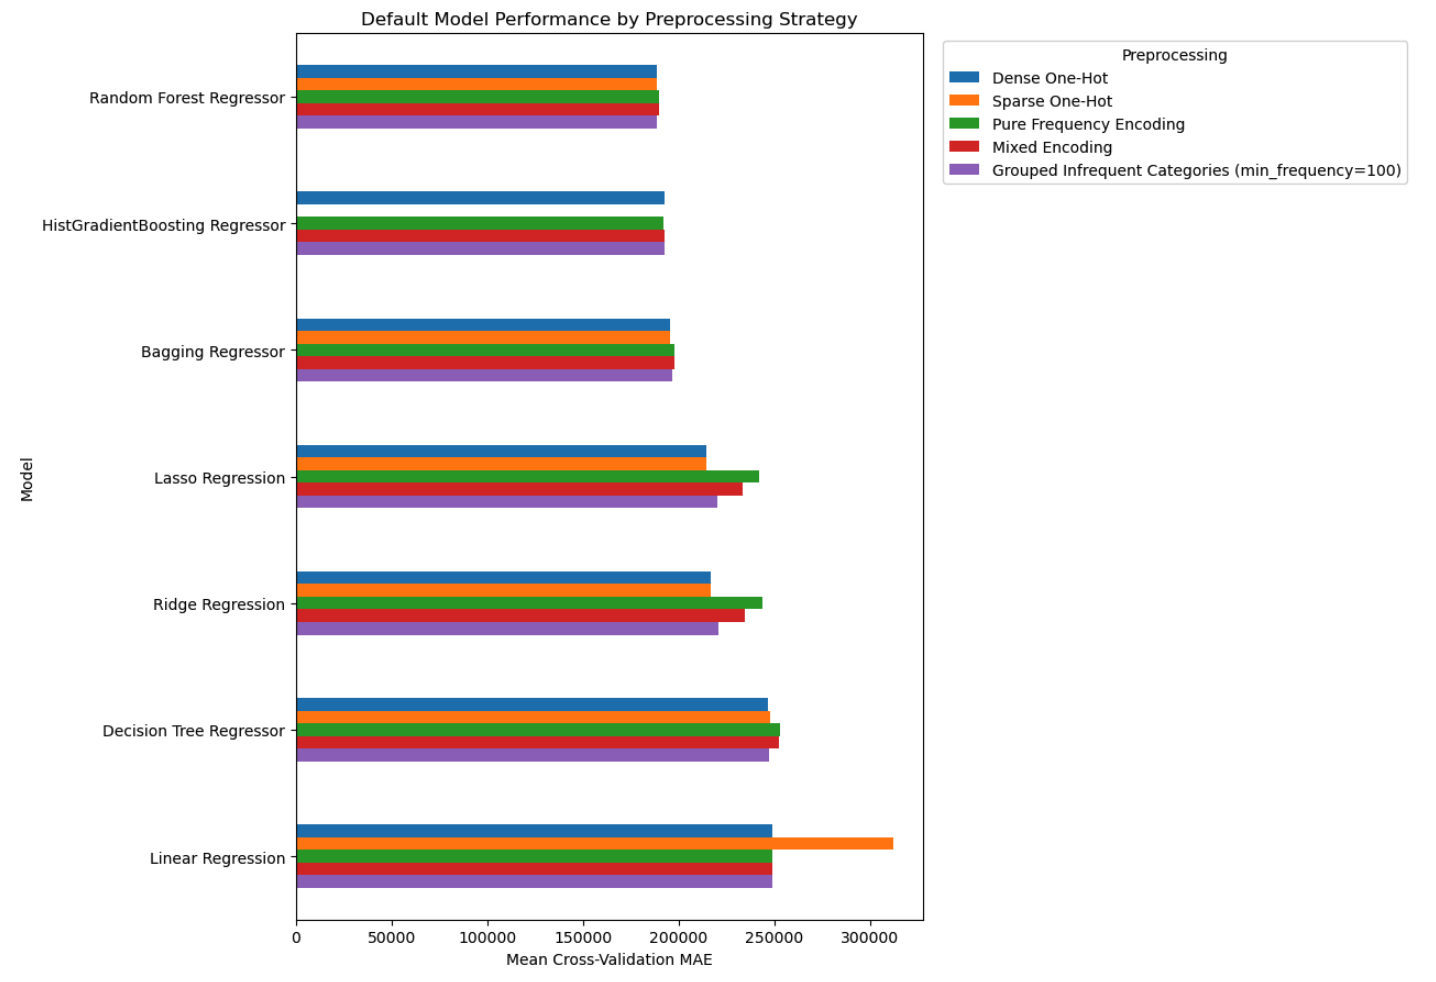

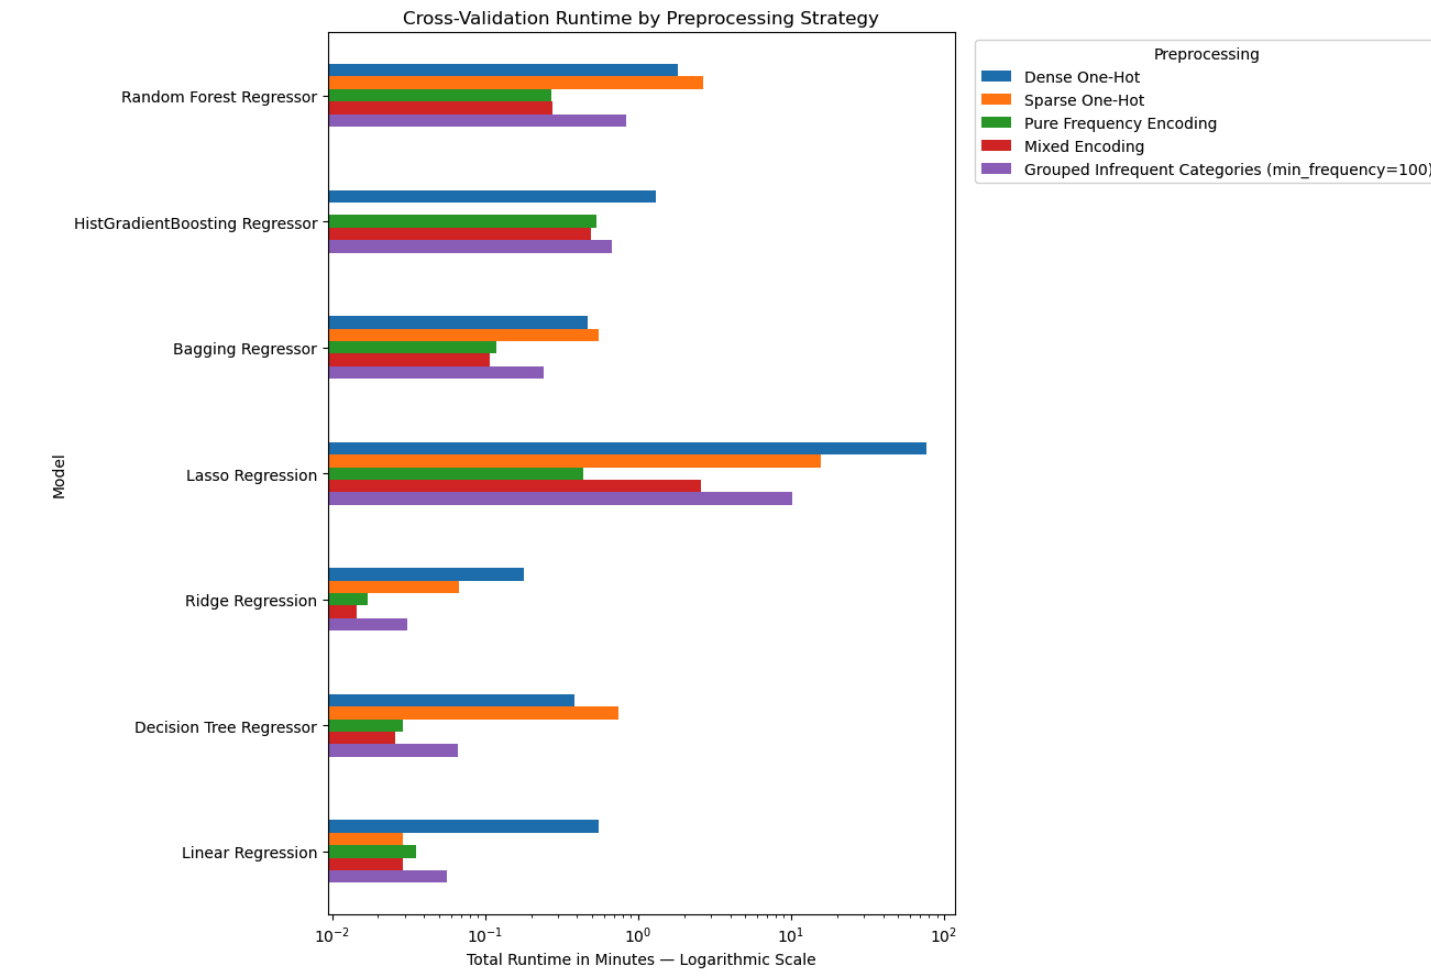

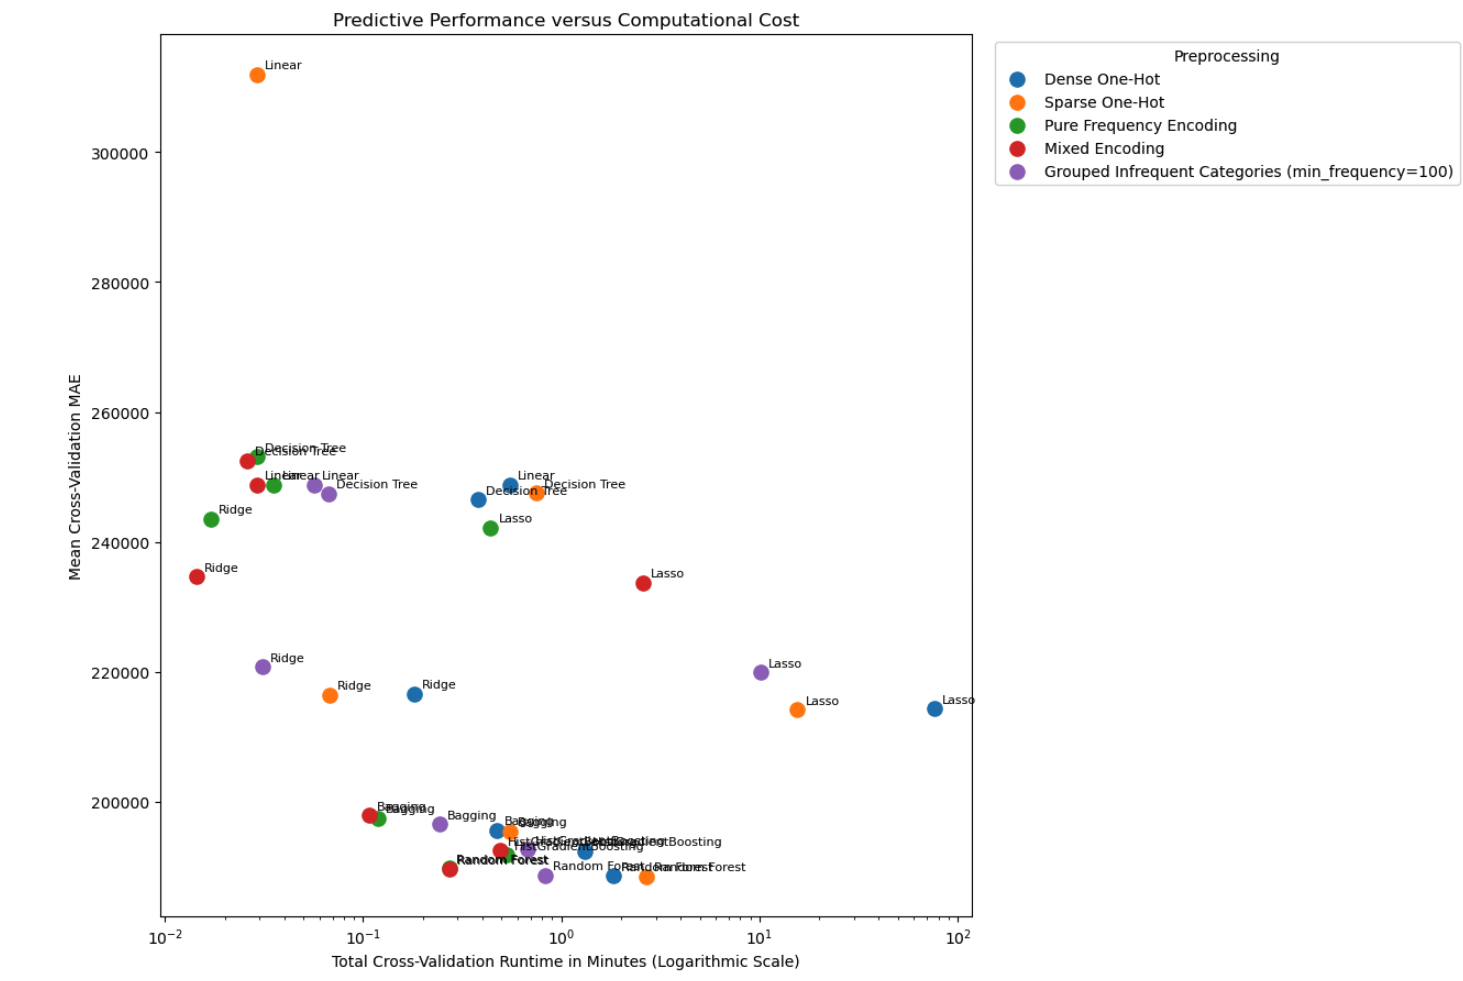

# Overall Conclusions

These experiments demonstrate that there is no single preprocessing strategy that is optimal in every situation. Each approach represents a different trade-off between predictive performance, memory usage, dimensionality, and computational cost.

- **Dense one-hot encoding** consistently produced the strongest predictive performance, although the advantage over the best alternatives was generally small. It remains an excellent baseline when memory usage and training time are not limiting factors.

- **Sparse one-hot encoding** preserves exactly the same information as dense one-hot encoding while dramatically reducing memory usage. It is the preferred choice when storing a large one-hot encoded matrix is the primary challenge. However, it does **not** reduce the number of generated features, and some estimators (such as `HistGradientBoostingRegressor`) cannot use sparse input.

- **Grouping infrequent categories** produced results that were remarkably close to full one-hot encoding while substantially reducing both the number of generated features and the computational cost. In this experiment, reducing the feature count from nearly 3,000 to about 600 had almost no effect on the strongest models while cutting training times roughly in half. This approach offers an excellent balance between simplicity, efficiency, and predictive performance.

- **Pure frequency encoding** produced the smallest representation of the categorical variables by replacing every categorical feature with a single numeric feature containing category frequencies. Although predictive performance was generally below the best one-hot-based approaches, the loss in accuracy was relatively modest while producing the greatest reduction in dimensionality. Frequency encoding is therefore an attractive option for very large datasets or resource-constrained environments where memory and training time are more important than achieving the absolute lowest validation error.

- **Mixed encoding** combined one-hot encoding for low-cardinality variables with frequency encoding for high-cardinality variables. In these experiments it generally outperformed pure frequency encoding while still dramatically reducing the number of generated features. Mixed encoding therefore represents a practical compromise between preserving categorical information and controlling feature dimensionality.

## Practical Recommendations

For datasets similar to this one, the following guidelines are reasonable:

- **Maximum predictive performance:** Use **dense one-hot encoding** when computational resources are not a concern.

- **Memory limitations:** Use **sparse one-hot encoding**, which preserves the complete one-hot representation while greatly reducing memory usage.

- **Best overall trade-off:** Use **grouping of infrequent categories**. It requires only a small modification to the standard `OneHotEncoder`, substantially reduces the number of generated features, and produced validation performance nearly identical to dense one-hot encoding in these experiments.

- **Very large datasets:** Consider **mixed encoding**, which preserves one-hot encoding where it is most useful while dramatically reducing the dimensionality of high-cardinality variables.

- **Extreme dimensionality reduction:** Use **pure frequency encoding** when minimizing feature count is the primary objective. Although some predictive accuracy is sacrificed, it produces an extremely compact representation and can substantially reduce computational requirements.

> **From an engineering perspective, grouping infrequent categories emerged as the strongest overall compromise, retaining nearly the predictive performance of dense one-hot encoding while requiring far fewer features and significantly less computation. Mixed encoding and pure frequency encoding extend this trade-off further, providing increasingly compact representations at the cost of modest reductions in predictive performance.**